## Imports

In [57]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import json
import os 
from datetime import datetime 
from pathlib import Path

## Ingestão

In [58]:
df_incidents = pd.read_csv('data/raw/incidents_master.csv')
df_market = pd.read_csv('data/raw/market_impact.csv')
df_financials = pd.read_csv('data/raw/financial_impact.csv')

In [104]:
df_incidents.head()

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at,_ingestion_timestamp
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,NaN,Multiple subsidiaries affected across 6 jurisd...,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-09
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,NaN,NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-09
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,NaN,NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-09
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,NaN,912,True,SFM,2021-03-15,...,https://www.mandiant.com/resources/blog/sterli...,company_pr,2,94.51,Gold,NaN,NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-09
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,NaN,1662,True,SQI,2021-12-04,...,NaN,company_pr,2,79.82,Silver,NaN,NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-09


In [60]:
df_financials.head()

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_method,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,NaN,9455354.49,2496545.93,90695.25,6756288.97,24642595.67,calculated,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,NaN,5857150.47,1809188.41,NaN,2691027.33,15306810.06,disclosed,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,34881599.59,calculated,NaN,NaN,NaN,26404111.95,10330703.43,NaN,31759649.99,71616414.97,disclosed,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,4682151.47,disclosed,NaN,NaN,NaN,3642946.48,1029035.85,NaN,1772460.33,9354133.80,disclosed,7648967.81,1.452521e+07,11098475.91,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,2684607.92,estimated,NaN,NaN,NaN,2574871.33,206822.23,NaN,NaN,5466301.48,estimated,3519806.28,6.755823e+06,6485647.58,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [61]:
df_market.head()

,incident_id,stock_ticker,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_index,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2023-0115-001,BITW,262.07,251.95,245.11,250.34,246.87,19782288,48767234,S&P 500 Information Technology,...,1.00000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2021-0315-001,SFM,9.37,9.09,8.73,8.78,8.67,458826,1421143,S&P 500 Consumer Discretionary,...,0.98240,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2021-1204-001,SQI,14.60,13.36,13.09,13.28,13.17,230932,354433,S&P 500 Information Technology,...,1.00000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0213-001,STUT.DE,5.34,5.43,5.27,5.36,5.37,2521343,6491913,S&P 500 Consumer Discretionary,...,1.00000,False,2.984412e+09,2.5748,0.027980,0.030972,24.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2025-0529-001,BAZA,465.19,441.08,410.45,428.36,429.49,1235984,3250371,S&P 500 Consumer Discretionary,...,0.38875,False,2.194296e+11,2.6298,0.025212,0.038232,313.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [62]:
print(df_incidents.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   incident_id               850 non-null    object 
 1   company_name              850 non-null    object 
 2   company_revenue_usd       850 non-null    float64
 3   country_hq                850 non-null    object 
 4   industry_primary          850 non-null    object 
 5   industry_secondary        153 non-null    object 
 6   employee_count            850 non-null    int64  
 7   is_public_company         850 non-null    bool   
 8   stock_ticker              412 non-null    object 
 9   incident_date             850 non-null    object 
 10  incident_date_estimated   850 non-null    bool   
 11  discovery_date            850 non-null    object 
 12  disclosure_date           850 non-null    object 
 13  attack_vector_primary     850 non-null    object 
 14  attack_vec

In [63]:
print(df_market.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   incident_id                      358 non-null    object 
 1   stock_ticker                     358 non-null    object 
 2   price_7d_before                  358 non-null    float64
 3   price_disclosure_day             358 non-null    float64
 4   price_1d_after                   358 non-null    float64
 5   price_7d_after                   358 non-null    float64
 6   price_30d_after                  358 non-null    float64
 7   volume_avg_30d_baseline          358 non-null    int64  
 8   volume_disclosure_day            358 non-null    int64  
 9   sector_index                     358 non-null    object 
 10  sector_return_same_period        358 non-null    float64
 11  abnormal_return_1d               358 non-null    float64
 12  abnormal_return_7d    

In [64]:
print(df_financials.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 778 entries, 0 to 777
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_id             778 non-null    object 
 1   direct_loss_usd         778 non-null    float64
 2   direct_loss_method      778 non-null    object 
 3   ransom_demanded_usd     206 non-null    float64
 4   ransom_paid_usd         86 non-null     float64
 5   ransom_source           86 non-null     object 
 6   recovery_cost_usd       778 non-null    float64
 7   legal_fees_usd          778 non-null    float64
 8   regulatory_fine_usd     132 non-null    float64
 9   insurance_payout_usd    435 non-null    float64
 10  total_loss_usd          778 non-null    float64
 11  total_loss_method       778 non-null    object 
 12  total_loss_lower_bound  778 non-null    float64
 13  total_loss_upper_bound  778 non-null    float64
 14  inflation_adjusted_usd  778 non-null    fl

In [65]:
print(df_incidents.isna().sum())

incident_id                   0
company_name                  0
company_revenue_usd           0
country_hq                    0
industry_primary              0
industry_secondary          697
employee_count                0
is_public_company             0
stock_ticker                438
incident_date                 0
incident_date_estimated       0
discovery_date                0
disclosure_date               0
attack_vector_primary         0
attack_vector_secondary     639
attack_chain                275
attributed_group            368
attribution_confidence      368
data_compromised_records    248
data_type                   248
systems_affected              0
downtime_hours              430
data_source_primary           0
data_source_secondary       464
data_source_type              0
confidence_tier               0
quality_score                 0
quality_grade                 0
review_flag                 780
notes                       636
created_at                    0
updated_

In [66]:
print(df_market.isna().sum())

incident_id                          0
stock_ticker                         0
price_7d_before                      0
price_disclosure_day                 0
price_1d_after                       0
price_7d_after                       0
price_30d_after                      0
volume_avg_30d_baseline              0
volume_disclosure_day                0
sector_index                         0
sector_return_same_period            0
abnormal_return_1d                   0
abnormal_return_7d                   0
abnormal_return_30d                  0
car_neg1_to_pos1                     0
car_0_to_7                           0
car_0_to_30                          0
car_0_to_90                          0
t_statistic_1d                       0
p_value_1d                           0
t_statistic_30d                      0
p_value_30d                          0
earnings_announcement_within_7d      0
market_cap_at_disclosure             0
volume_ratio_disclosure              0
pre_incident_volatility_3

In [67]:
print(df_financials.isna().sum())

incident_id                 0
direct_loss_usd             0
direct_loss_method          0
ransom_demanded_usd       572
ransom_paid_usd           692
ransom_source             692
recovery_cost_usd           0
legal_fees_usd              0
regulatory_fine_usd       646
insurance_payout_usd      343
total_loss_usd              0
total_loss_method           0
total_loss_lower_bound      0
total_loss_upper_bound      0
inflation_adjusted_usd      0
cpi_index_used              0
notes                     530
created_at                  0
updated_at                  0
dtype: int64


### Metadados de ingestão

In [68]:
df_incidents['_ingestion_timestamp'] = datetime.now().strftime('%Y-%m-%d')
df_market['_ingestion_timestamp'] = datetime.now().strftime('%Y-%m-%d')
df_financials['_ingestion_timestamp'] = datetime.now().strftime('%Y-%m-%d')

## Conversão de tipos

In [69]:
# Datas
for col in ['incident_date', 'discovery_date', 'disclosure_date', '_ingestion_timestamp']:
    df_incidents[col] = pd.to_datetime(df_incidents[col], errors='coerce')

df_market['_ingestion_timestamp'] = pd.to_datetime(df_market['_ingestion_timestamp'], errors='coerce')

df_financials['_ingestion_timestamp'] = pd.to_datetime(df_financials['_ingestion_timestamp'], errors='coerce')

# created_at e updated_at têm fuso
df_incidents['created_at'] = pd.to_datetime(df_incidents['created_at'], utc=True, errors='coerce')
df_incidents['updated_at']  = pd.to_datetime(df_incidents['updated_at'],  utc=True, errors='coerce')

df_market['created_at'] = pd.to_datetime(df_market['created_at'], utc=True, errors='coerce')
df_market['updated_at']  = pd.to_datetime(df_market['updated_at'],  utc=True, errors='coerce')

df_financials['created_at'] = pd.to_datetime(df_financials['created_at'], utc=True, errors='coerce')
df_financials['updated_at']  = pd.to_datetime(df_financials['updated_at'],  utc=True, errors='coerce')

print("Tipos após conversão:")
print('--'*15, 'Incidents', '--'*15)
print(df_incidents[['incident_date', 'discovery_date', 'disclosure_date', '_ingestion_timestamp', 'created_at', 'updated_at']].dtypes)
print('--'*15, 'Market', '--'*15)
print(df_market[['_ingestion_timestamp', 'created_at', 'updated_at']].dtypes)
print('--'*15, 'Financials', '--'*15)
print(df_financials[['_ingestion_timestamp', 'created_at', 'updated_at']].dtypes)

Tipos após conversão:
------------------------------ Incidents ------------------------------
incident_date                datetime64[ns]
discovery_date               datetime64[ns]
disclosure_date              datetime64[ns]
_ingestion_timestamp         datetime64[ns]
created_at              datetime64[ns, UTC]
updated_at              datetime64[ns, UTC]
dtype: object
------------------------------ Market ------------------------------
_ingestion_timestamp         datetime64[ns]
created_at              datetime64[ns, UTC]
updated_at              datetime64[ns, UTC]
dtype: object
------------------------------ Financials ------------------------------
_ingestion_timestamp         datetime64[ns]
created_at              datetime64[ns, UTC]
updated_at              datetime64[ns, UTC]
dtype: object


## Persistência

In [70]:
Path('data/bronze').mkdir(parents=True, exist_ok=True)

df_incidents.to_parquet('./data/bronze/bronze_incidents.parquet')
df_market.to_parquet('./data/bronze/bronze_market.parquet')
df_financials.to_parquet('./data/bronze/bronze_financials.parquet')

In [71]:
#tamanho dataset original em bits
print('Tamanho do dataset  incidents original em bits: ' + str(Path('data/raw/incidents_master.csv').stat().st_size))
print('Tamanho do dataset  market original em bits: ' + str(Path('data/raw/market_impact.csv').stat().st_size))
print('Tamanho do dataset  financials original em bits: ' + str(Path('data/raw/financial_impact.csv').stat().st_size))
print('---------------------------------------------------------')
print('Tamanho do bronze_incidents em bits: ' + str(Path('data/bronze/bronze_incidents.parquet').stat().st_size))
print('Tamanho do bronze_financials em bits: ' + str(Path('data/bronze/bronze_financials.parquet').stat().st_size))
print('Tamanho do bronze_market em bits: ' + str(Path('data/bronze/bronze_market.parquet').stat().st_size))

Tamanho do dataset  incidents original em bits: 438941
Tamanho do dataset  market original em bits: 109318
Tamanho do dataset  financials original em bits: 170578
---------------------------------------------------------
Tamanho do bronze_incidents em bits: 132912
Tamanho do bronze_financials em bits: 74898
Tamanho do bronze_market em bits: 92005


In [72]:
df_bronze_incidents = pd.read_parquet('./data/bronze/bronze_incidents.parquet')
df_bronze_market = pd.read_parquet('./data/bronze/bronze_market.parquet')
df_bronze_financials = pd.read_parquet('./data/bronze/bronze_financials.parquet')

### Verificando nulos

In [73]:
def print_nulos(df):
    missing=pd.DataFrame(df.isnull().sum(),columns=["Null Values"])
    missing["% Missing Values"]=(df.isna().sum()/len(df)*100)
    missing = missing[missing["% Missing Values"] > 0].sort_values(by="% Missing Values", ascending=False)
    print(missing.head(100))

In [74]:
print('bronze_incidents')
print_nulos(df_bronze_incidents)

print('\n--------\nbronze_market')
print_nulos(df_bronze_market)

print('\n--------\nbronze_financials')
print_nulos(df_bronze_financials)


bronze_incidents
                          Null Values  % Missing Values
review_flag                       780         91.764706
industry_secondary                697         82.000000
attack_vector_secondary           639         75.176471
notes                             636         74.823529
data_source_secondary             464         54.588235
stock_ticker                      438         51.529412
downtime_hours                    430         50.588235
attribution_confidence            368         43.294118
attributed_group                  368         43.294118
attack_chain                      275         32.352941
data_type                         248         29.176471
data_compromised_records          248         29.176471

--------
bronze_market
                        Null Values  % Missing Values
notes                           266         74.301676
days_to_price_recovery           36         10.055866

--------
bronze_financials
                      Null Values  % Miss

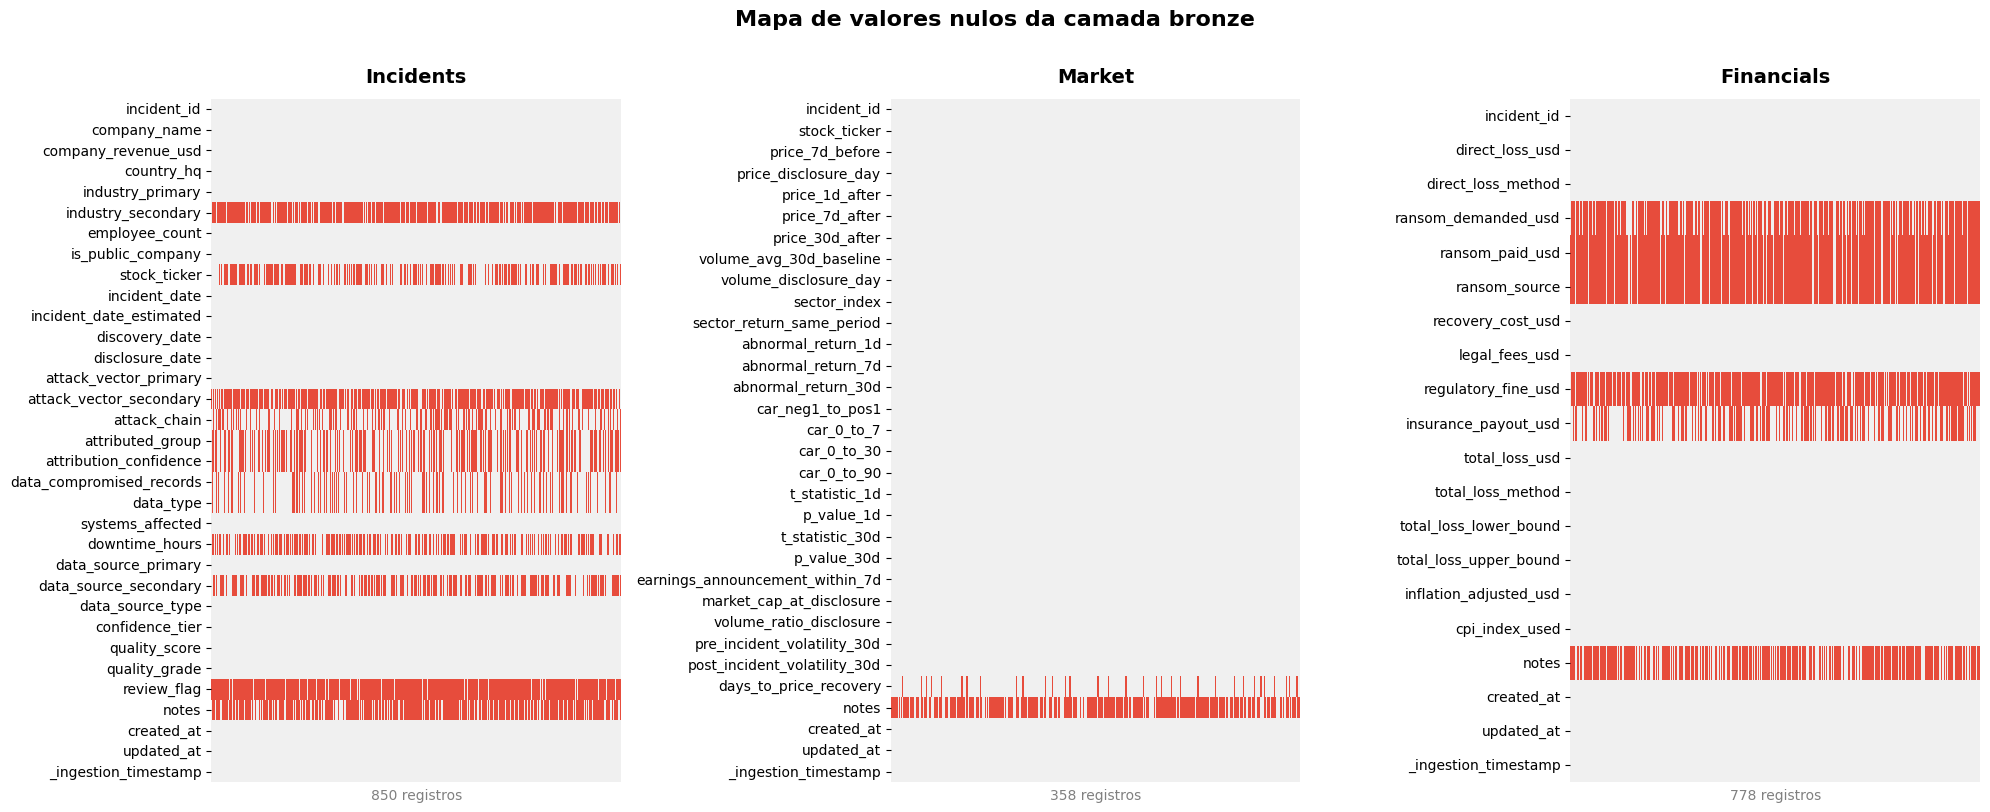

In [75]:
# Visualizacao do mapa de nulos
fig, axes = plt.subplots(1, 3, figsize=(20,8))

datasets = {
    "Incidents": df_bronze_incidents,
    "Market": df_bronze_market,
    "Financials": df_bronze_financials,
}

for ax, (title, df) in zip(axes, datasets.items()):
    sns.heatmap(
        df.isnull().T,
        cmap=['#F0F0F0','#E74C3C'],
        cbar=False, 
        ax=ax, 
        xticklabels=False, 
        yticklabels=True
    )
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(f"{len(df):,} registros", fontsize=10, color="gray")
    ax.set_ylabel("")

fig.suptitle("Mapa de valores nulos da camada bronze", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Buscando duplicatas

In [76]:
datasets = [df_bronze_incidents, df_bronze_market, df_bronze_financials]

for df in datasets:
    print(df[df.duplicated()])

Empty DataFrame
Columns: [incident_id, company_name, company_revenue_usd, country_hq, industry_primary, industry_secondary, employee_count, is_public_company, stock_ticker, incident_date, incident_date_estimated, discovery_date, disclosure_date, attack_vector_primary, attack_vector_secondary, attack_chain, attributed_group, attribution_confidence, data_compromised_records, data_type, systems_affected, downtime_hours, data_source_primary, data_source_secondary, data_source_type, confidence_tier, quality_score, quality_grade, review_flag, notes, created_at, updated_at, _ingestion_timestamp]
Index: []

[0 rows x 33 columns]
Empty DataFrame
Columns: [incident_id, stock_ticker, price_7d_before, price_disclosure_day, price_1d_after, price_7d_after, price_30d_after, volume_avg_30d_baseline, volume_disclosure_day, sector_index, sector_return_same_period, abnormal_return_1d, abnormal_return_7d, abnormal_return_30d, car_neg1_to_pos1, car_0_to_7, car_0_to_30, car_0_to_90, t_statistic_1d, p_value_

In [77]:
datasets = [df_bronze_incidents, df_bronze_market, df_bronze_financials]

for df in datasets:
    print(df[df.duplicated(subset=['incident_id'])])


Empty DataFrame
Columns: [incident_id, company_name, company_revenue_usd, country_hq, industry_primary, industry_secondary, employee_count, is_public_company, stock_ticker, incident_date, incident_date_estimated, discovery_date, disclosure_date, attack_vector_primary, attack_vector_secondary, attack_chain, attributed_group, attribution_confidence, data_compromised_records, data_type, systems_affected, downtime_hours, data_source_primary, data_source_secondary, data_source_type, confidence_tier, quality_score, quality_grade, review_flag, notes, created_at, updated_at, _ingestion_timestamp]
Index: []

[0 rows x 33 columns]
Empty DataFrame
Columns: [incident_id, stock_ticker, price_7d_before, price_disclosure_day, price_1d_after, price_7d_after, price_30d_after, volume_avg_30d_baseline, volume_disclosure_day, sector_index, sector_return_same_period, abnormal_return_1d, abnormal_return_7d, abnormal_return_30d, car_neg1_to_pos1, car_0_to_7, car_0_to_30, car_0_to_90, t_statistic_1d, p_value_

## Metadados de Ingestão — Bronze


In [78]:
import hashlib
from datetime import datetime
from pathlib import Path

lista_metadados = []

for item in ['data/raw/incidents_master.csv', 'data/raw/market_impact.csv', 'data/raw/financial_impact.csv']:

    arquivo = Path(item)

    # Hash SHA-256 do arquivo original
    sha256 = hashlib.sha256(arquivo.read_bytes()).hexdigest()

    metadata_bronze = {
        'arquivo': arquivo.name,
        'linhas': len(df),
        'colunas': len(df.columns),
        'tamanho_bytes': arquivo.stat().st_size,
        'hash_sha256': sha256,
        'data_carga': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'camada': 'bronze'
    }

    lista_metadados.append(metadata_bronze)

    print(json.dumps(metadata_bronze, indent=2))

# Salvar metadados em JSON ao lado do parquet
Path('data/bronze').mkdir(parents=True, exist_ok=True)
with open('data/bronze/metadata_bronze.json', 'w') as f:
    json.dump(lista_metadados, f, indent=2)

print('\nMetadados salvos em data/bronze/metadata_bronze.json')


{
  "arquivo": "incidents_master.csv",
  "linhas": 778,
  "colunas": 20,
  "tamanho_bytes": 438941,
  "hash_sha256": "9819d9ad6baeadca4c503d1146def6504da32e42b9e14e38b0008b24ffc84225",
  "data_carga": "2026-04-09 23:50:42",
  "camada": "bronze"
}
{
  "arquivo": "market_impact.csv",
  "linhas": 778,
  "colunas": 20,
  "tamanho_bytes": 109318,
  "hash_sha256": "d7f4ef0645bbc50f9e4cd159800f1f3f69f87fb5a9d0489f987f1ebc0fb827c1",
  "data_carga": "2026-04-09 23:50:42",
  "camada": "bronze"
}
{
  "arquivo": "financial_impact.csv",
  "linhas": 778,
  "colunas": 20,
  "tamanho_bytes": 170578,
  "hash_sha256": "9e375eb6f35b70d40166ae03e62cfe809d3e976bb9951498e6f5f2ce78b46679",
  "data_carga": "2026-04-09 23:50:42",
  "camada": "bronze"
}

Metadados salvos em data/bronze/metadata_bronze.json


## Relatório de Qualidade dos Dados — Bronze


In [79]:
def gerar_relatorio_qualidade(df, nome_camada='bronze'):
    total_linhas = len(df)
    duplicatas_totais = df.duplicated().sum()

    def classificar_status(pct):
        if pct > 50:   return 'CRITICO - >50% nulos'
        if pct > 20:   return 'ATENCAO - >20% nulos'
        return 'OK'

    relatorio = [
        {
            'coluna':    col,
            'tipo':      str(df[col].dtype),
            'nulos':     (nulos := df[col].isnull().sum()),
            'pct_nulo':  round(nulos / total_linhas * 100, 2),
            'duplicados': df[col].duplicated().sum() if df[col].dtype == 'object' else None,
            'status':    classificar_status(nulos / total_linhas * 100),
        }
        for col in df.columns
    ]

    df_rel = pd.DataFrame(relatorio)

    sep = '=' * 52
    print(f'\n{sep}')
    print(f'  Relatório de Qualidade — Camada {nome_camada.upper()}')
    print(sep)
    print(f'  Total de linhas  : {total_linhas:,}')
    print(f'  Linhas duplicadas: {duplicatas_totais:,}')
    print(f'{sep}\n')
    print(df_rel[['coluna', 'tipo', 'nulos', 'pct_nulo', 'status']].to_string(index=False))
    print()

    return df_rel


datasets = {
    'incidents':  df_bronze_incidents,
    'market':     df_bronze_market,
    'financials': df_bronze_financials,
}

relatorios = {
    nome: gerar_relatorio_qualidade(df, 'bronze')
    for nome, df in datasets.items()
}

for nome, df_rel in relatorios.items():
    df_rel.to_csv(f'data/bronze/relatorio_qualidade_bronze_{nome}.csv', index=False)


  Relatório de Qualidade — Camada BRONZE
  Total de linhas  : 850
  Linhas duplicadas: 0

                  coluna                tipo  nulos  pct_nulo               status
             incident_id              object      0      0.00                   OK
            company_name              object      0      0.00                   OK
     company_revenue_usd             float64      0      0.00                   OK
              country_hq              object      0      0.00                   OK
        industry_primary              object      0      0.00                   OK
      industry_secondary              object    697     82.00 CRITICO - >50% nulos
          employee_count               int64      0      0.00                   OK
       is_public_company                bool      0      0.00                   OK
            stock_ticker              object    438     51.53 CRITICO - >50% nulos
           incident_date      datetime64[ns]      0      0.00                  

---
# Camada Silver


In [80]:
df_silver_incidents = df_bronze_incidents.copy()
df_silver_market = df_bronze_market.copy()
df_silver_financials = df_bronze_financials.copy()

### Ingestão 

# Limpeza, Tratamento de Datas e Padronização

### Removendo linhas totalmente duplicadas

In [81]:
df_silver_incidents = df_bronze_incidents.drop_duplicates()
df_silver_market = df_bronze_market.drop_duplicates()
df_silver_financials = df_bronze_financials.drop_duplicates()

### Diagnóstico inicial após remoção de duplicatas

In [82]:
print(f"incidents  — shape: {df_silver_incidents.shape},  duplicatas removidas: {df_bronze_incidents.duplicated().sum()}")
print(f"market     — shape: {df_silver_market.shape},  duplicatas removidas: {df_bronze_market.duplicated().sum()}")
print(f"financials — shape: {df_silver_financials.shape},  duplicatas removidas: {df_bronze_financials.duplicated().sum()}")


incidents  — shape: (850, 33),  duplicatas removidas: 0
market     — shape: (358, 32),  duplicatas removidas: 0
financials — shape: (778, 20),  duplicatas removidas: 0


### Remoção de colunas sem impacto para ML

In [83]:
for df in [df_silver_incidents, df_silver_market, df_silver_financials]:
    df.drop(columns='notes', inplace=True)

### Padronização de colunas categóricas — incidents

Aplicamos `lower().strip()` para eliminar inconsistências de capitalização. `data_type` tinha valores como `'PII'` e `'IP'` em maiúsculas.

In [84]:
cols_cat_incidents = [
    'attack_vector_primary', 'attack_vector_secondary',
    'country_hq', 'data_type', 'attribution_confidence',
    'data_source_type', 'quality_grade'
]
for col in cols_cat_incidents:
    df_silver_incidents[col] = df_silver_incidents[col].str.lower().str.strip()

print("Valores únicos — attack_vector_primary:", df_silver_incidents['attack_vector_primary'].unique().tolist())
print("Valores únicos — data_type:            ", df_silver_incidents['data_type'].unique().tolist())
print("Valores únicos — country_hq (amostra): ", df_silver_incidents['country_hq'].unique()[:8].tolist())


Valores únicos — attack_vector_primary: ['ransomware', 'phishing', 'trojan', 'data_breach', 'apt', 'ddos', 'supply_chain', 'malware', 'backdoor']
Valores únicos — data_type:             ['mixed', None, 'pii', 'health', 'credentials', 'financial', 'ip']
Valores únicos — country_hq (amostra):  ['us', 'gb', 'de', 'at', 'ca', 'au', 'fr', 'ch']


### Padronização de colunas categóricas — market

In [ ]:
df_silver_market['sector_index'] = df_silver_market['sector_index'].str.strip()
print("Setores:", df_silver_market['sector_index'].unique().tolist())

Setores: ['S&P 500 Information Technology', 'S&P 500 Consumer Discretionary', 'S&P 500 Industrials', 'S&P 500 Financials', 'S&P 500', 'S&P 500 Health Care', 'S&P 500 Utilities', 'S&P 500 Real Estate', 'S&P 500 Communication Services', 'S&P 500 Energy']


### Padronização de colunas categóricas — financials

In [86]:
cols_cat_fin = ['direct_loss_method', 'total_loss_method', 'ransom_source']
for col in cols_cat_fin:
    df_silver_financials[col] = df_silver_financials[col].str.lower().str.strip()

print("direct_loss_method:", df_silver_financials['direct_loss_method'].unique().tolist())
print("total_loss_method: ", df_silver_financials['total_loss_method'].unique().tolist())


direct_loss_method: ['disclosed', 'calculated', 'estimated']
total_loss_method:  ['calculated', 'disclosed', 'estimated']


### Tratamento de nulos — incidents

Colunas opcionais recebem valores semânticos (`'desconhecido'`, `'nao_capital_aberto'`). Numéricas com ausência estrutural recebem `0`.

In [87]:
# Categóricas opcionais
df_silver_incidents['attack_vector_secondary']= df_silver_incidents['attack_vector_secondary'].fillna('desconhecido')
df_silver_incidents['attributed_group']= df_silver_incidents['attributed_group'].fillna('desconhecido')
df_silver_incidents['attribution_confidence']= df_silver_incidents['attribution_confidence'].fillna('desconhecido')
df_silver_incidents['data_type']= df_silver_incidents['data_type'].fillna('desconhecido')
df_silver_incidents['stock_ticker']= df_silver_incidents['stock_ticker'].fillna('nao_capital_aberto')
df_silver_incidents['industry_secondary']= df_silver_incidents['industry_secondary'].fillna('nao_informado')
df_silver_incidents['attack_chain']= df_silver_incidents['attack_chain'].fillna('nao_informado')
df_silver_incidents['data_source_secondary']= df_silver_incidents['data_source_secondary'].fillna('nao_informado')

# Numéricas com ausência estrutural (empresa sem inatividade ou sem registros comprometidos)
df_silver_incidents['downtime_hours']= df_silver_incidents['downtime_hours'].fillna(0)
df_silver_incidents['data_compromised_records']= df_silver_incidents['data_compromised_records'].fillna(0)

print("Nulos restantes em incidents:")
print(df_silver_incidents.isnull().sum()[df_silver_incidents.isnull().sum() > 0])


Nulos restantes em incidents:
review_flag    780
dtype: int64


### Tratamento de nulos — market

`days_to_price_recovery` nulo significa que o preço não se recuperou no período observado — substituímos por `-1` como sentinela já que `0` ficaria muito ambiguo.

In [88]:
df_silver_market['days_to_price_recovery'] = df_silver_market['days_to_price_recovery'].fillna(-1)

print("Nulos restantes em market:")
remaining = df_silver_market.isnull().sum()
print(remaining[remaining > 0] if remaining[remaining > 0].any() else "Nenhum nulo relevante.")


Nulos restantes em market:
Nenhum nulo relevante.


### Tratamento de nulos — financials

Colunas de resgate são nulas por design para incidentes sem envolvimento de ransomware — usamos `0` para distinguir de ausência de dado.

In [89]:
df_silver_financials['ransom_demanded_usd']  = df_silver_financials['ransom_demanded_usd'].fillna(0)
df_silver_financials['ransom_paid_usd']      = df_silver_financials['ransom_paid_usd'].fillna(0)
df_silver_financials['regulatory_fine_usd']  = df_silver_financials['regulatory_fine_usd'].fillna(0)
df_silver_financials['insurance_payout_usd'] = df_silver_financials['insurance_payout_usd'].fillna(0)
df_silver_financials['ransom_source']        = df_silver_financials['ransom_source'].fillna('nao_aplicavel')

print("Nulos restantes em financials:")
remaining = df_silver_financials.isnull().sum()
print(remaining[remaining > 0] if remaining[remaining > 0].any() else "Nenhum nulo relevante.")


Nulos restantes em financials:
Nenhum nulo relevante.


### Remoção de colunas com risco de Data Leakage

Colunas produzidas por revisão humana pós-análise ou que derivam diretamente do alvo não devem fazer parte do conjunto de features.

In [90]:
leakage_incidents = ['quality_score', 'quality_grade', 'confidence_tier', 'review_flag']
df_silver_incidents = df_silver_incidents.drop(columns=leakage_incidents)
print(f"incidents — removidas: {leakage_incidents} | shape: {df_silver_incidents.shape}")


incidents — removidas: ['quality_score', 'quality_grade', 'confidence_tier', 'review_flag'] | shape: (850, 28)


### Tabela Checklist Anti-Leakage

In [91]:
checklist_leakage = [
    {'dataset': 'incidents', 'coluna': 'quality_score',           'risco': 'ALTO',  'acao': 'REMOVIDA',              'justificativa': 'Score calculado pós-incidente — vaza informação do futuro'},
    {'dataset': 'incidents', 'coluna': 'quality_grade',           'risco': 'ALTO',  'acao': 'REMOVIDA',              'justificativa': 'Grade derivada do quality_score'},
    {'dataset': 'incidents', 'coluna': 'confidence_tier',         'risco': 'ALTO',  'acao': 'REMOVIDA',              'justificativa': 'Tier de confiança atribuído pós-análise'},
    {'dataset': 'incidents', 'coluna': 'review_flag',             'risco': 'ALTO',  'acao': 'REMOVIDA',              'justificativa': 'Flag de revisão manual — indisponível no momento do incidente'},
    {'dataset': 'incidents', 'coluna': 'disclosure_date',         'risco': 'MEDIO', 'acao': 'MANTIDA',               'justificativa': 'Usar apenas como feature temporal, não como proxy do target'},
    {'dataset': 'incidents', 'coluna': 'attribution_confidence',  'risco': 'BAIXO', 'acao': 'MANTIDA',               'justificativa': 'Informação disponível no momento; tratada como categórica'},
    {'dataset': 'incidents', 'coluna': 'data_compromised_records','risco': 'MEDIO', 'acao': 'USADA NO LABEL (excluir das features)', 'justificativa': 'Compõe o label _is_high_impact'},
    {'dataset': 'incidents', 'coluna': 'downtime_hours',          'risco': 'MEDIO', 'acao': 'USADA NO LABEL (excluir das features)', 'justificativa': 'Compõe o label _is_high_impact'},
    {'dataset': 'market',    'coluna': 'car_0_to_90',             'risco': 'MEDIO', 'acao': 'MANTIDA',               'justificativa': 'Retorno acumulado 90d — usar apenas para análise pós-evento'},
    {'dataset': 'market',    'coluna': 'days_to_price_recovery',  'risco': 'MEDIO', 'acao': 'MANTIDA',               'justificativa': 'Resultado pós-incidente — não usar como feature preditiva'},
    {'dataset': 'financials','coluna': 'total_loss_usd',          'risco': 'ALTO',  'acao': 'USADA NO LABEL (excluir das features)', 'justificativa': 'Compõe o label _is_severe_loss'},
]

df_leakage = pd.DataFrame(checklist_leakage)
print(df_leakage.to_string(index=False))

Path('data/silver').mkdir(parents=True, exist_ok=True)
df_leakage.to_csv('data/silver/checklist_anti_leakage.csv', index=False)
print('\nChecklist salvo em data/silver/checklist_anti_leakage.csv')


   dataset                   coluna risco                                  acao                                                 justificativa
 incidents            quality_score  ALTO                              REMOVIDA     Score calculado pós-incidente — vaza informação do futuro
 incidents            quality_grade  ALTO                              REMOVIDA                               Grade derivada do quality_score
 incidents          confidence_tier  ALTO                              REMOVIDA                       Tier de confiança atribuído pós-análise
 incidents              review_flag  ALTO                              REMOVIDA Flag de revisão manual — indisponível no momento do incidente
 incidents          disclosure_date MEDIO                               MANTIDA   Usar apenas como feature temporal, não como proxy do target
 incidents   attribution_confidence BAIXO                               MANTIDA     Informação disponível no momento; tratada como categórica
 incid

### Criação dos Labels para Machine Learning

- **incidents** → `_is_high_impact`: 1 se registros comprometidos > 100k **ou** downtime > 72h
- **financials** → `_is_severe_loss`: 1 se prejuízo total > mediana
- **market** → `_is_significant_drop`: 1 se retorno anormal em 30d < -5%

In [92]:
# Label incidents
df_silver_incidents['_is_high_impact'] = (
    (df_silver_incidents['data_compromised_records'] > 100_000) |
    (df_silver_incidents['downtime_hours'] > 72)
).astype(int)

# Label financials
mediana_loss = df_silver_financials['total_loss_usd'].median()
df_silver_financials['_is_severe_loss'] = (
    df_silver_financials['total_loss_usd'] > mediana_loss
).astype(int)

# Label market
df_silver_market['_is_significant_drop'] = (
    df_silver_market['abnormal_return_30d'] < -0.05
).astype(int)

print("=== Distribuição dos Labels ===")
print(f"\n[incidents] _is_high_impact:")
print(df_silver_incidents['_is_high_impact'].value_counts().to_string())
print(f"  Proporção de alto impacto: {df_silver_incidents['_is_high_impact'].mean():.2%}")

print(f"\n[financials] _is_severe_loss  (mediana = R$ {mediana_loss:,.0f}):")
print(df_silver_financials['_is_severe_loss'].value_counts().to_string())
print(f"  Proporção de perda severa: {df_silver_financials['_is_severe_loss'].mean():.2%}")

print(f"\n[market] _is_significant_drop (retorno anormal 30d < -5%):")
print(df_silver_market['_is_significant_drop'].value_counts().to_string())
print(f"  Proporção de queda significativa: {df_silver_market['_is_significant_drop'].mean():.2%}")


=== Distribuição dos Labels ===

[incidents] _is_high_impact:
_is_high_impact
0    479
1    371
  Proporção de alto impacto: 43.65%

[financials] _is_severe_loss  (mediana = R$ 16,564,915):
_is_severe_loss
1    389
0    389
  Proporção de perda severa: 50.00%

[market] _is_significant_drop (retorno anormal 30d < -5%):
_is_significant_drop
0    329
1     29
  Proporção de queda significativa: 8.10%


### Documentação das Transformações Silver

In [105]:
transformacoes = [
    {'dataset': 'todos',       'etapa': '1', 'acao': 'Remoção de duplicatas',          'detalhes': 'drop_duplicates() — linhas 100% idênticas removidas'},
    {'dataset': 'todos',       'etapa': '2', 'acao': 'Padronização categórica',        'detalhes': 'str.lower().strip() em todas as colunas de texto categórico'},
    {'dataset': 'incidents',   'etapa': '3', 'acao': 'Preenchimento de nulos',         'detalhes': 'attack_vector_secondary, attributed_group, attribution_confidence, data_type → "desconhecido"; stock_ticker → "nao_capital_aberto"; downtime_hours, data_compromised_records → 0'},
    {'dataset': 'market',      'etapa': '3', 'acao': 'Preenchimento de nulos',         'detalhes': 'days_to_price_recovery → -1 (sentinela: preço não recuperado)'},
    {'dataset': 'financials',  'etapa': '3', 'acao': 'Preenchimento de nulos',         'detalhes': 'ransom_demanded/paid, regulatory_fine, insurance_payout → 0; ransom_source → "nao_aplicavel"'},
    {'dataset': 'incidents',   'etapa': '4', 'acao': 'Remoção anti-leakage',           'detalhes': 'quality_score, quality_grade, confidence_tier, review_flag removidas'},
    {'dataset': 'incidents',   'etapa': '5', 'acao': 'Label _is_high_impact',          'detalhes': '1 se data_compromised_records > 100k OU downtime_hours > 72'},
    {'dataset': 'financials',  'etapa': '5', 'acao': 'Label _is_severe_loss',          'detalhes': '1 se total_loss_usd > mediana do dataset'},
    {'dataset': 'market',      'etapa': '5', 'acao': 'Label _is_significant_drop',     'detalhes': '1 se abnormal_return_30d < -0.05 (queda anormal > 5%)'},
]

df_trans = pd.DataFrame(transformacoes)
print(df_trans.to_string(index=False))

df_trans.to_csv('data/silver/documentacao_transformacoes.csv', index=False)
print('\nDocumentação salva.')


   dataset etapa                       acao                                                                                                                                                                         detalhes
     todos     1      Remoção de duplicatas                                                                                                                              drop_duplicates() — linhas 100% idênticas removidas
     todos     2    Padronização categórica                                                                                                                      str.lower().strip() em todas as colunas de texto categórico
 incidents     3     Preenchimento de nulos attack_vector_secondary, attributed_group, attribution_confidence, data_type → "desconhecido"; stock_ticker → "nao_capital_aberto"; downtime_hours, data_compromised_records → 0
    market     3     Preenchimento de nulos                                                                         

### Salvando a Camada Silver

In [94]:
Path('data/silver').mkdir(parents=True, exist_ok=True)

df_silver_incidents.to_parquet('data/silver/silver_incidents.parquet', index=False)
df_silver_market.to_parquet('data/silver/silver_market.parquet', index=False)
df_silver_financials.to_parquet('data/silver/silver_financials.parquet', index=False)

for nome, df in [('incidents', df_silver_incidents), ('market', df_silver_market), ('financials', df_silver_financials)]:
    size = Path(f'data/silver/silver_{nome}.parquet').stat().st_size
    print(f"silver_{nome}.parquet | shape: {df.shape} | {size:,} bytes")


silver_incidents.parquet | shape: (850, 29) | 124,947 bytes
silver_market.parquet | shape: (358, 32) | 90,366 bytes
silver_financials.parquet | shape: (778, 20) | 72,869 bytes


---
## Análise Exploratória de Dados (EDA)

### Mapa de Nulos — Camada Silver

Confirmação visual de que os nulos foram tratados.

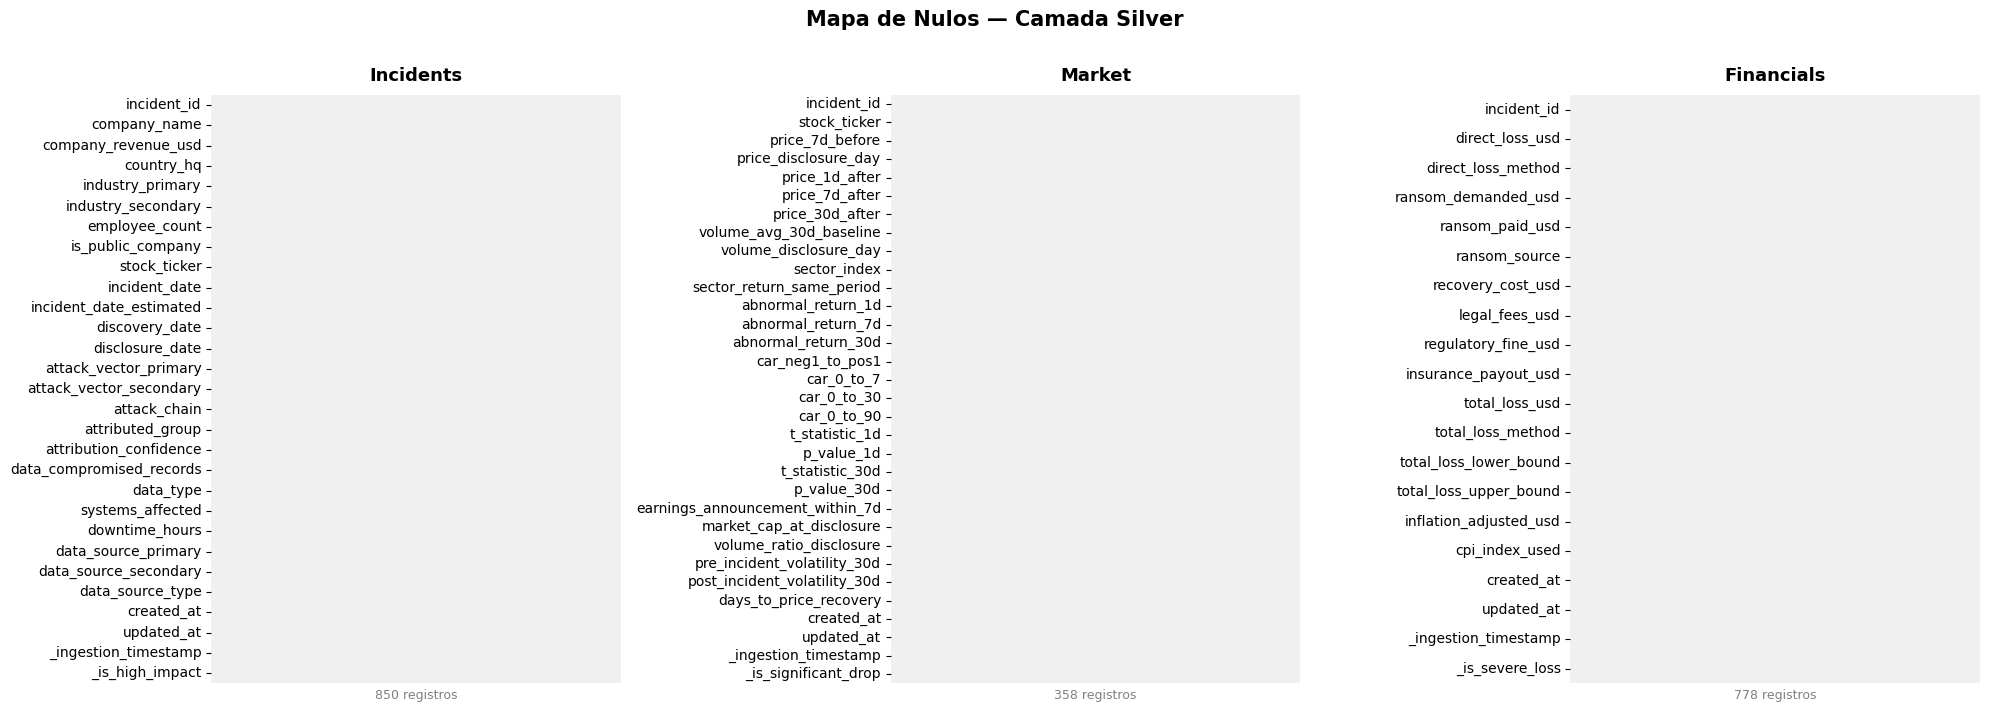

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

datasets_silver = {
    "Incidents": df_silver_incidents,
    "Market":    df_silver_market,
    "Financials":df_silver_financials,
}

for ax, (title, df) in zip(axes, datasets_silver.items()):
    sns.heatmap(
        df.isnull().T,
        cmap=['#F0F0F0', '#E74C3C'],
        cbar=False, 
        ax=ax,
        xticklabels=False, 
        yticklabels=True
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(f"{len(df):,} registros", fontsize=9, color='gray')

fig.suptitle("Mapa de Nulos — Camada Silver", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Gráfico 1 — Volume e Taxa de Alto Impacto por Vetor de Ataque

Identifica quais vetores geram incidentes mais severos (>`100k` registros ou `>72h` inatividade).

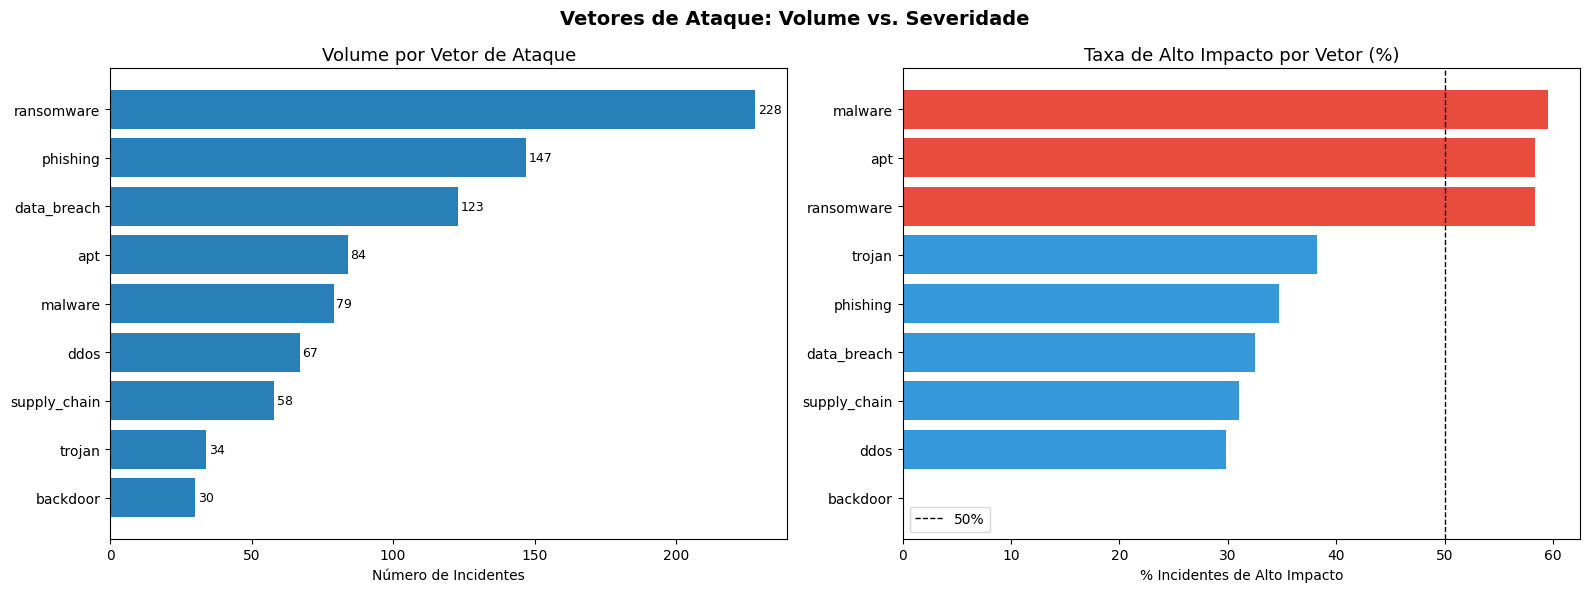

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

contagem = df_silver_incidents['attack_vector_primary'].value_counts()
axes[0].barh(contagem.index, contagem.values, color='#2980b9')
axes[0].set_title('Volume por Vetor de Ataque', fontsize=13)
axes[0].set_xlabel('Número de Incidentes')
axes[0].invert_yaxis()
for i, v in enumerate(contagem.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

taxa = df_silver_incidents.groupby('attack_vector_primary')['_is_high_impact'].mean().sort_values(ascending=False)
cores = ['#e74c3c' if v > 0.5 else '#3498db' for v in taxa.values]
axes[1].barh(taxa.index, taxa.values * 100, color=cores)
axes[1].axvline(50, color='black', linestyle='--', linewidth=1, label='50%')
axes[1].set_title('Taxa de Alto Impacto por Vetor (%)', fontsize=13)
axes[1].set_xlabel('% Incidentes de Alto Impacto')
axes[1].legend()
axes[1].invert_yaxis()

fig.suptitle('Vetores de Ataque: Volume vs. Severidade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Gráfico 2 — Evolução Trimestral dos Incidentes (2021–2025)

Série temporal segmentada por nível de impacto.

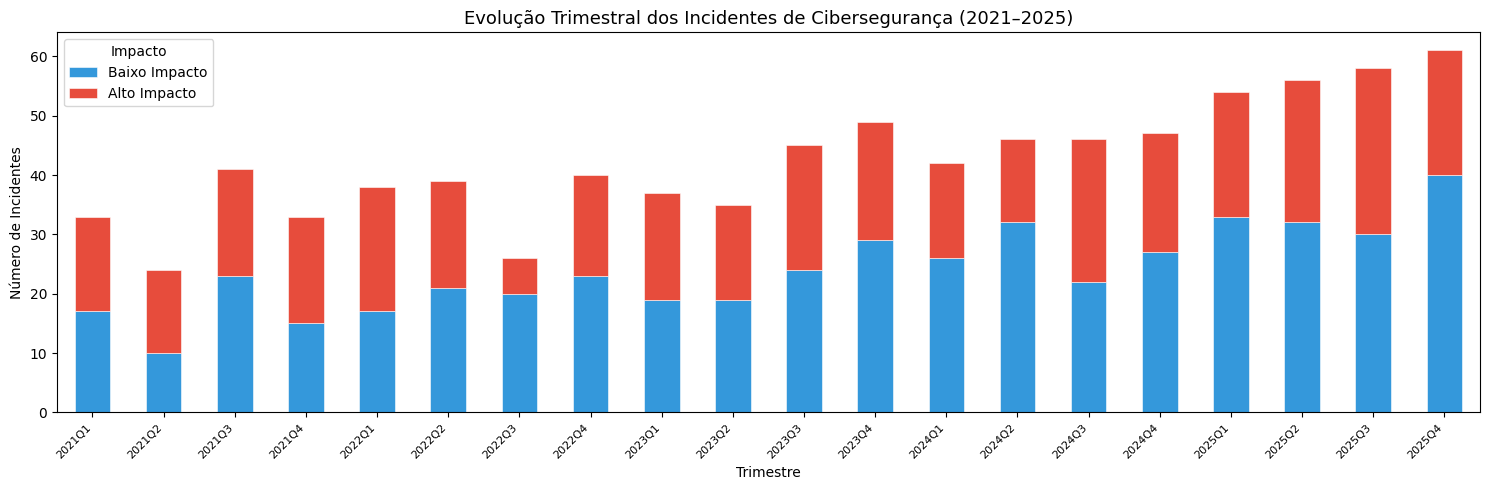

In [108]:
df_temp = df_silver_incidents.copy()
df_temp['trimestre'] = df_temp['incident_date'].dt.to_period('Q').astype(str)

evolucao = df_temp.groupby(['trimestre', '_is_high_impact']).size().unstack(fill_value=0)
evolucao.columns = ['Baixo Impacto', 'Alto Impacto']

fig, ax = plt.subplots(figsize=(15, 5))
evolucao.plot(kind='bar', stacked=True, ax=ax,
              color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=0.4)
ax.set_title('Evolução Trimestral dos Incidentes de Cibersegurança (2021–2025)', fontsize=13)
ax.set_xlabel('Trimestre')
ax.set_ylabel('Número de Incidentes')
ax.legend(title='Impacto')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


### Gráfico 3 — Prejuízo Total (USD) por Vetor de Ataque

Cruzamento entre incidents e financials para entender o custo médio de cada tipo de ataque.

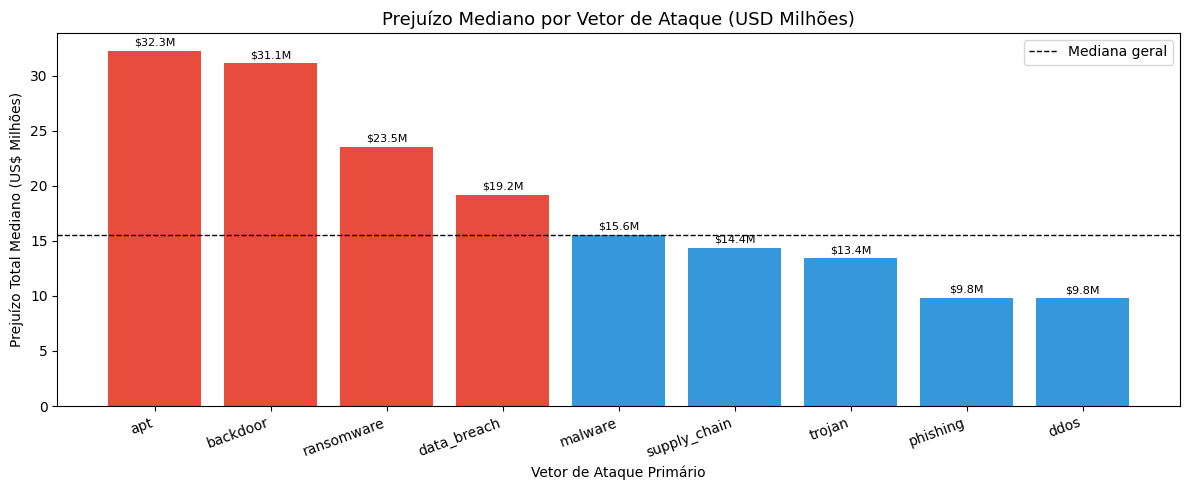

In [109]:
df_fin_joined = df_silver_incidents[['incident_id', 'attack_vector_primary', '_is_high_impact']].merge(
    df_silver_financials[['incident_id', 'total_loss_usd']],
    on='incident_id', how='inner'
)

mediana_por_vetor = (df_fin_joined.groupby('attack_vector_primary')['total_loss_usd']
                     .median().sort_values(ascending=False) / 1e6)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(mediana_por_vetor.index, mediana_por_vetor.values,
              color=['#e74c3c' if v > mediana_por_vetor.median() else '#3498db'
                     for v in mediana_por_vetor.values])
ax.set_title('Prejuízo Mediano por Vetor de Ataque (USD Milhões)', fontsize=13)
ax.set_xlabel('Vetor de Ataque Primário')
ax.set_ylabel('Prejuízo Total Mediano (US$ Milhões)')
ax.axhline(mediana_por_vetor.median(), color='black', linestyle='--', linewidth=1, label='Mediana geral')
ax.legend()
plt.xticks(rotation=20, ha='right')
for bar, val in zip(bars, mediana_por_vetor.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.1f}M', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


### Gráfico 4 — Top 10 Países × Vetores de Ataque (Heatmap)

Frequência de cada vetor nos 10 países com mais incidentes registrados.

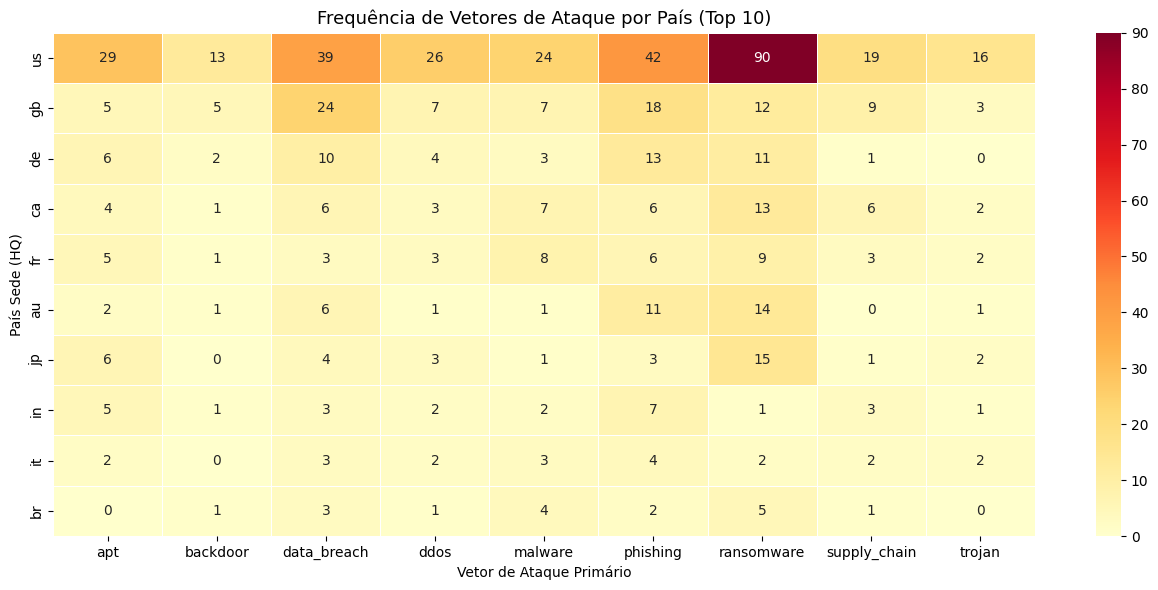

In [113]:
top10 = df_silver_incidents['country_hq'].value_counts().head(10).index
df_hm = df_silver_incidents[df_silver_incidents['country_hq'].isin(top10)]

pivot = df_hm.pivot_table(index='country_hq', columns='attack_vector_primary',
                           values='incident_id', aggfunc='count', fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, linecolor='white')
plt.title('Frequência de Vetores de Ataque por País (Top 10)', fontsize=13)
plt.xlabel('Vetor de Ataque Primário')
plt.ylabel('País Sede (HQ)')
plt.tight_layout()
plt.show()


---
## Data Lineage do Pipeline (3 datasets)

# DATA LINEAGE — PIPELINE MEDALION (3 FONTES)

## ORIGENS

incidents_master.csv | market_impact.csv | financial_impact.csv
(850 linhas) | (358 linhas) | (778 linhas)

## CAMADA BRONZE

Transformações aplicadas em todos:
- ✔ Padronização de nomes de colunas (snake_case)
- ✔ Conversão de tipos básicos (datas, numéricos)
- ✔ Adição de _ingestion_timestamp
- ✔ Metadados: hash SHA-256, tamanho, contagem de linhas
- ✔ Relatório de qualidade gerado (nulos, duplicatas)

### VALIDAÇÕES APLICADAS
- % nulos por coluna
- Detecção de duplicatas
- Checagem de datas fora do padrão

## CAMADA SILVER

### [incidents] silver_incidents.parquet
- ✔ Remoção de duplicatas
- ✔ Padronização categórica (lower/strip)
- ✔ Preenchimento de nulos semântico
- ✔ Anti-leakage: quality_score, quality_grade, confidence_tier, review_flag → REMOVIDAS
- ✔ Label: _is_high_impact

### [market] silver_market.parquet
- ✔ Remoção de duplicatas
- ✔ days_to_price_recovery: nulo → -1 (sentinela)
- ✔ Padronização categórica (sector_index)
- ✔ Label: _is_significant_drop (abnormal_return_30d < -5%)

### [financials] silver_financials.parquet
- ✔ Remoção de duplicatas
- ✔ Nulos de resgate/multa → 0 (estruturais por design)
- ✔ Padronização categórica (loss_method, ransom_source)
- ✔ Label: _is_severe_loss (total_loss_usd > mediana)

## DESTINO — Datasets prontos para Machine Learning

Targets disponíveis: _is_high_impact | _is_severe_loss | _is_significant_drop